In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, Flatten, GlobalMaxPooling2D
from tensorflow.keras.models import Model

In [3]:
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train/255.0
X_test = X_test/255.0
y_train = y_train.flatten()
y_test = y_test.flatten()
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1939s 11us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)


In [4]:
K = len(set(y_train))
print(f"Number of classes: {K}")

Number of classes: 10


In [5]:
# Building the model using functional API
i = Input(shape=X_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation="relu")(x)
x = Flatten()(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(K, activation="softmax")(x)

model = Model(i, x)

In [13]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

r = model.fit(X_train,y_train, validation_data=(X_test,y_test), epochs = 15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.7231 - loss: 0.7813 - val_accuracy: 0.6866 - val_loss: 0.9042
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7339 - loss: 0.7553 - val_accuracy: 0.7068 - val_loss: 0.8430
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7390 - loss: 0.7316 - val_accuracy: 0.7128 - val_loss: 0.8309
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7466 - loss: 0.7102 - val_accuracy: 0.6997 - val_loss: 0.8663
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7521 - loss: 0.6926 - val_accuracy: 0.7149 - val_loss: 0.8240
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7610 - loss: 0.6725 - val_accuracy: 0.7050 - val_loss: 0.8558
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7654 - loss: 0.6620 - val_accuracy: 0.7154 - val_loss: 0.8187
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7709 -

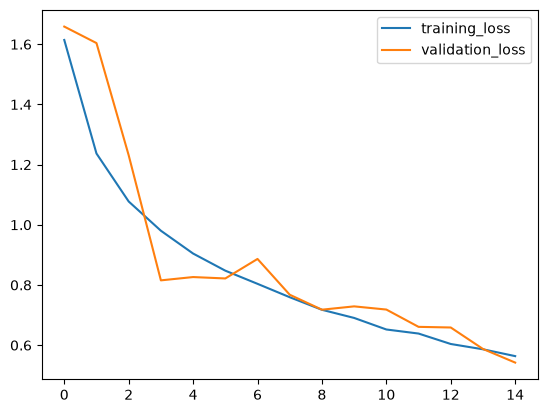

In [26]:
plt.plot(r.history['loss'],label='training_loss')
plt.plot(r.history['val_loss'], label='validation_loss')
plt.legend()

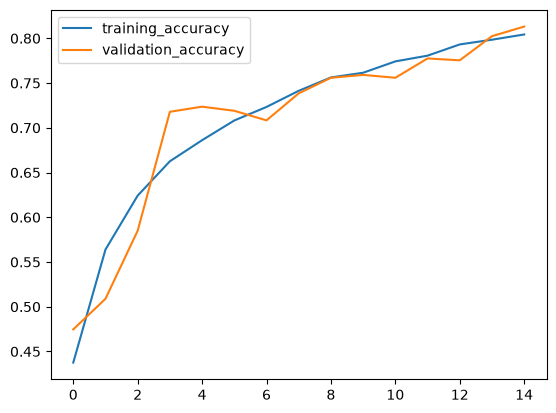

In [27]:
plt.plot(r.history['accuracy'], label='training_accuracy')
plt.plot(r.history['val_accuracy'], label='validation_accuracy')
plt.legend()

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(y_test)
print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
[3 8 8 ... 5 1 7]
[3 8 1 ... 5 1 7]


In [17]:
labels='''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

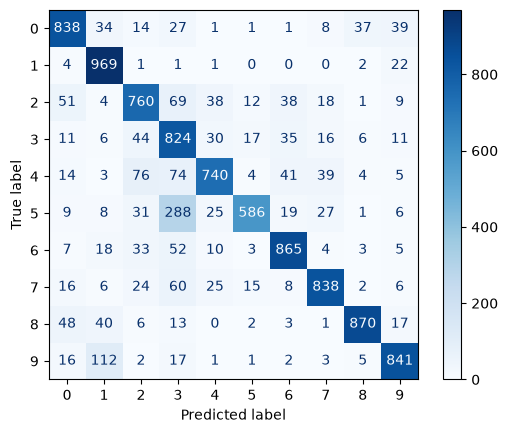

In [29]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, values_format="d")

Text(0.5, 1.0, 'True Label: bird, Predicted Label: frog')

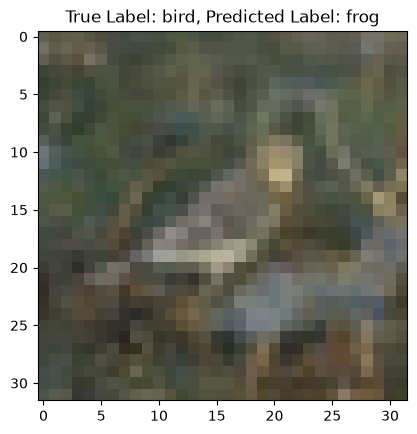

In [30]:
misclassified_idx = np.where(y_pred != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(X_test[i], cmap='gray')
plt.title(f"True Label: {labels[y_test[i]]}, Predicted Label: {labels[y_pred[i]]}")

### BATCH Normalization and DATA Augmentation

In [20]:
from tensorflow.keras.layers import BatchNormalization

In [21]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [24]:
# Model with batch normalization and data augmentation
i = Input(shape=X_train[0].shape)
x = data_augmentation(i)
x = Conv2D(32, (3, 3), padding='same', activation="relu")(x)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), padding='same', activation="relu")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3, 3), padding='same', activation="relu")(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), padding='same', activation="relu")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(128, (3, 3), padding='same', activation="relu")(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), padding='same', activation="relu")(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dropout(0.3)(x)
x = Dense(1024, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(K, activation="softmax")(x)

model = Model(i, x)

In [25]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

r = model.fit(X_train,y_train, validation_data=(X_test,y_test), epochs = 15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 83ms/step - accuracy: 0.4376 - loss: 1.6142 - val_accuracy: 0.4747 - val_loss: 1.6586
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 127s 81ms/step - accuracy: 0.5639 - loss: 1.2369 - val_accuracy: 0.5089 - val_loss: 1.6039
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 123s 79ms/step - accuracy: 0.6242 - loss: 1.0775 - val_accuracy: 0.5850 - val_loss: 1.2310
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 118s 75ms/step - accuracy: 0.6626 - loss: 0.9803 - val_accuracy: 0.7179 - val_loss: 0.8154
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 119s 76ms/step - accuracy: 0.6861 - loss: 0.9045 - val_accuracy: 0.7236 - val_loss: 0.8264
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 124s 79ms/step - accuracy: 0.7082 - loss: 0.8476 - val_accuracy: 0.7190 - val_loss: 0.8217
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 118s 75ms/step - accuracy: 0.7233 - loss: 0.8039 - val_accuracy: 0.7083 - val_loss: 0.8866
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 118s 75ms/step - accuracy: 